# Introduction

This notebook generates the global UMAP of all major cell types (Fig. 1C).

**Input**: `all_seurat_obj.RDS` — preprocessed Seurat object containing all cells after quality control.  

**Workflow**: QC filtering → Normalization → Variable gene selection → Balanced PCA (weighted by cell category) → UMAP

In [1]:
fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

# Data wrangling
library(dplyr)
library(stringr)
library(purrr)

# Plot
library(ggplot2)
library(ggthemes)
library(patchwork)
library(ggrepel)

# single cell
library(Seurat)
library(singlecellmethods)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘data.table’ was built under R version 4.1.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Warning message:
“package ‘tidyr’ was built under R version 4.1.3”

Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose


Warning message:
“package ‘stringr’ was built under R version 4.1.3”
Warning message:
“package ‘lobstr’ was built under R version 4.1.3”
Warning message:
“package ‘glue’ was built under R version 4.1.3”
Warning message:
“package ‘forcats’ was built under R version 4.1.3”
Warning message:
“package ‘readr’ was built under R version 4.1.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.1.3”
Loading required package

In [2]:
# a base scatter plot function
generate_colors_tableau <- function(input_vec, verbose = FALSE){
    input_levels <- unique(input_vec)
    num_levels <- input_levels %>% length()
    if (num_levels < 10) pal_name <- "Tableau 10"
    else pal_name <- "Tableau 20"
    # if (num_levels < 10) pal_name <- "Classic 10"
    # else pal_name <- "Classic 20"
    
    pal <- tableau_color_pal(pal_name)
    max_n <- attr(pal, "max_n")
    if (num_levels < max_n) {
        col_vec <- pal(num_levels)
    } else {
        col_vec <- colorRampPalette(pal(max_n))(num_levels)
    }
    names(col_vec) <- stringr::str_sort(input_levels, numeric = TRUE)
    if (verbose){
        message("Number of unique values: ", num_levels)
        message("Palette chosen: ", pal_name)
    } 
    return(col_vec)
}

plot_scatter <- function(
    embedding, meta_data, label_name, 
    highlight = NULL, no_guides = TRUE, do_labels = TRUE, do_points = TRUE,
    do_density = FALSE, palette_use = NULL, random = TRUE, bg_point = FALSE,
    pt_size = 4, point_size = 0.1, base_size = 20, legend_point_size = 4, nice_names
){
    if(is.null(palette_use)){ # assign color to each category
        palette_use <- generate_colors_tableau(meta_data[[label_name]])
    }
    if(!is.null(highlight)){
        # palette_use[!(names(palette_use) %in% highlight)] <- 'gray'
        
        # Don't assign color to nonhighlight labels
        palette_use <- palette_use[(names(palette_use) %in% highlight)] 
    }

    
    embedding <- embedding[, 1:2]
    colnames(embedding) <- c('X1', 'X2')
    plt_df <- embedding %>% 
        data.frame() %>%
        cbind(meta_data)

    if(random) plt_df <- plt_df %>% dplyr::sample_frac(1L)
    
    plt_df$given_name <- plt_df[[label_name]]
    
    if (!missing(nice_names)) {
        plt_df <- plt_df %>% 
            dplyr::inner_join(nice_names, by = "given_name") %>% 
            subset(nice_name != "" & !is.na(nice_name))
        
        plt_df[[label_name]] <- plt_df$nice_name        
    }

    plt <- plt_df %>%
        ggplot2::ggplot(aes(x = X1, y = X2)) +
            theme_test(base_size = base_size) +
            theme(panel.background = element_rect(fill = NA, color = "black")) + 
            guides(color = guide_legend(override.aes = list(
                stroke = 1, alpha = 1, shape = 16, size = legend_point_size)), alpha = FALSE) +
            scale_color_manual(values = palette_use, na.value = 'gray') + 
            scale_fill_manual(values = palette_use) +
            theme(plot.title = element_text(hjust = .5)) +
            NULL


    if(bg_point){
        if(point_size == '.'){
            plt <- plt + geom_point(data = plt_df %>% select(-all_of(label_name)),
                                    color = 'gray', shape = '.')
        }
        else{
            plt <- plt + geom_point(data = plt_df %>% select(-all_of(label_name)),
                                    color = 'gray', size = point_size)
        } 
    }

    
    if(do_points){
        if(point_size == '.'){
            plt <- plt + geom_point(aes(color = .data[[label_name]]), shape = '.')
        }
        else{
            plt <- plt + geom_point(aes(color = .data[[label_name]]), size = point_size)
        } 
    } 
    
    if(do_density) plt <- plt + geom_density_2d()

    if(do_labels){
        data_labels <- plt_df %>%
            dplyr::group_by(.data[[label_name]]) %>%
            dplyr::summarise(X1 = mean(X1), X2 = mean(X2)) %>%
            dplyr::ungroup()
        
        if(!is.null(highlight)){ # hide non-highlight labels
            data_labels <- data_labels %>% 
                mutate('{label_name}' := if_else(
                    .data[[label_name]] %in% highlight,
                    .data[[label_name]], ''))
        }
        
        plt <- plt + geom_label_repel(
            data = data_labels, aes(label = .data[[label_name]], fill = .data[[label_name]]),
            label.size = NA, color = "white", size = pt_size, alpha = 1,
            # segment.size =0, 
            max.overlaps = Inf, min.segment.length = 0, segment.color = 'black'
        )
    }
    
    if(no_guides) plt <- plt + guides(col = FALSE, fill = FALSE, alpha = FALSE)

    return(plt)
}

In [3]:
labUMAP <- function(
    obj, input_reduc, output_reduc,
    ret_extra = 'fgraph', random_seed = 1, key = 'UMAP_', ...
){
    set.seed(random_seed)
    U <- uwot::umap(obj[[input_reduc]]@cell.embeddings, ret_extra = ret_extra, ...)
    
    colnames(U$embedding) = c('UMAP1', 'UMAP2')
    rownames(U$fgraph) = colnames(U$fgraph) = Cells(obj)
    
    obj[[output_reduc]] <- Seurat::CreateDimReducObject(
        embeddings = U$embedding,
        assay = 'RNA',
        key = key,
        global = TRUE
    )
    
    U_graph = Seurat::as.Graph(U$fgraph)
    DefaultAssay(U_graph) <- DefaultAssay(obj)
    output_fgraph_reduc <- paste0(output_reduc, '_fgraph')
    obj[[output_fgraph_reduc]] <- U_graph
    return(obj)
}

In [5]:
obj <- readRDS(file.path('all_seurat_obj.RDS'))

In [6]:
obj@meta.data %>% colnames()

[1] "orig.ident"                 "nCount_RNA"                
 [3] "nFeature_RNA"               "idx"                       
 [5] "sampleID"                   "specimenID"                
 [7] "patientID"                  "treatment"                 
 [9] "tissueSite"                 "response"                  
[11] "pctChange"                  "MMRstatus"                 
[13] "pctChangeNoPre"             "n_genes_by_counts"         
[15] "total_counts"               "total_counts_mt"           
[17] "pct_counts_mt"              "n_genes"                   
[19] "leiden"                     "doublet_score"             
[21] "predicted_doublet"          "category"                  
[23] "midcategory"                "RECIST"                    
[25] "PFSmo"                      "sex"                       
[27] "resp_tx"                    "S.Score"                   
[29] "G2M.Score"                  "Phase"                     
[31] "ccDiff.Score"               "L1_RNA_snn_res.0.01_leiden"
[33] "L1_RNA_snn_res.0.02_leiden" "L1_RNA_snn_res.0.04_leiden"
[35] "L1_RNA_snn_res.0.08_leiden" "L1_RNA_snn_res.0.16_leiden"
[37] "L1_RNA_snn_res.0.32_leiden" "L1_RNA_snn_res.0.64_leiden"
[39] "L1_RNA_snn_res.1.28_leiden" "L1_RNA_snn_res.2.56_leiden"
[41] "L2_RNA_snn_res.0.01_leiden" "L2_RNA_snn_res.0.02_leiden"
[43] "L2_RNA_snn_res.0.04_leiden" "L2_RNA_snn_res.0.08_leiden"
[45] "L2_RNA_snn_res.0.16_leiden" "L2_RNA_snn_res.0.32_leiden"
[47] "resolution_L1"              "cell_type_L1"              
[49] "resolution_L2"              "cell_type_L2"              
[51] "cell_type_L2_long"          "jon_cell_type"

In [7]:
obj@meta.data %>% with(table(category))

category
          B Endothelial  Epithelial  Fibroblast Hepatocytes        Mast 
      16783        9063       95421        8546        5081         851 
    Myeloid      Plasma           T 
      43516        4343      143814 

In [8]:
obj

An object of class Seurat 
33200 features across 327418 samples within 1 assay 
Active assay: RNA (33200 features, 0 variable features)

# Before QC

In [9]:
obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^MT-")

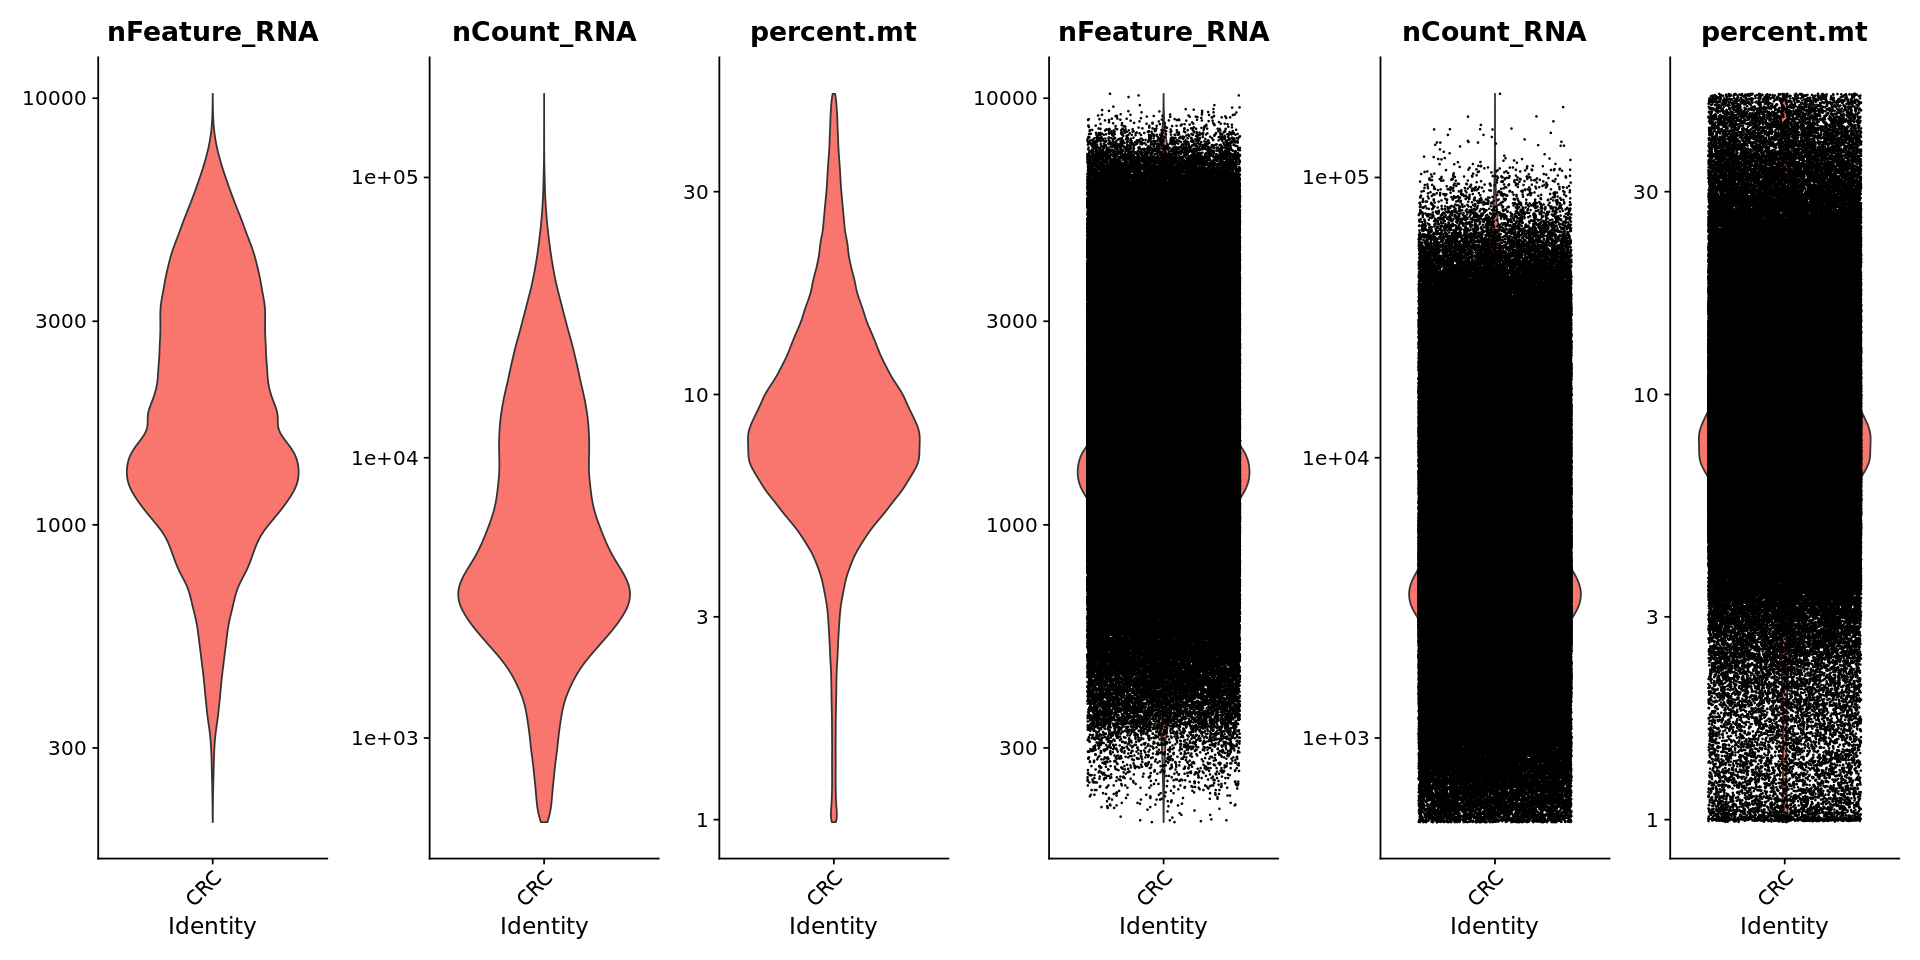

In [10]:
fig.size(8,16)
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3,
        log = TRUE, pt.size = 0, raster = FALSE) |
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3,
        log = TRUE, pt.size = 0.1, raster = FALSE)

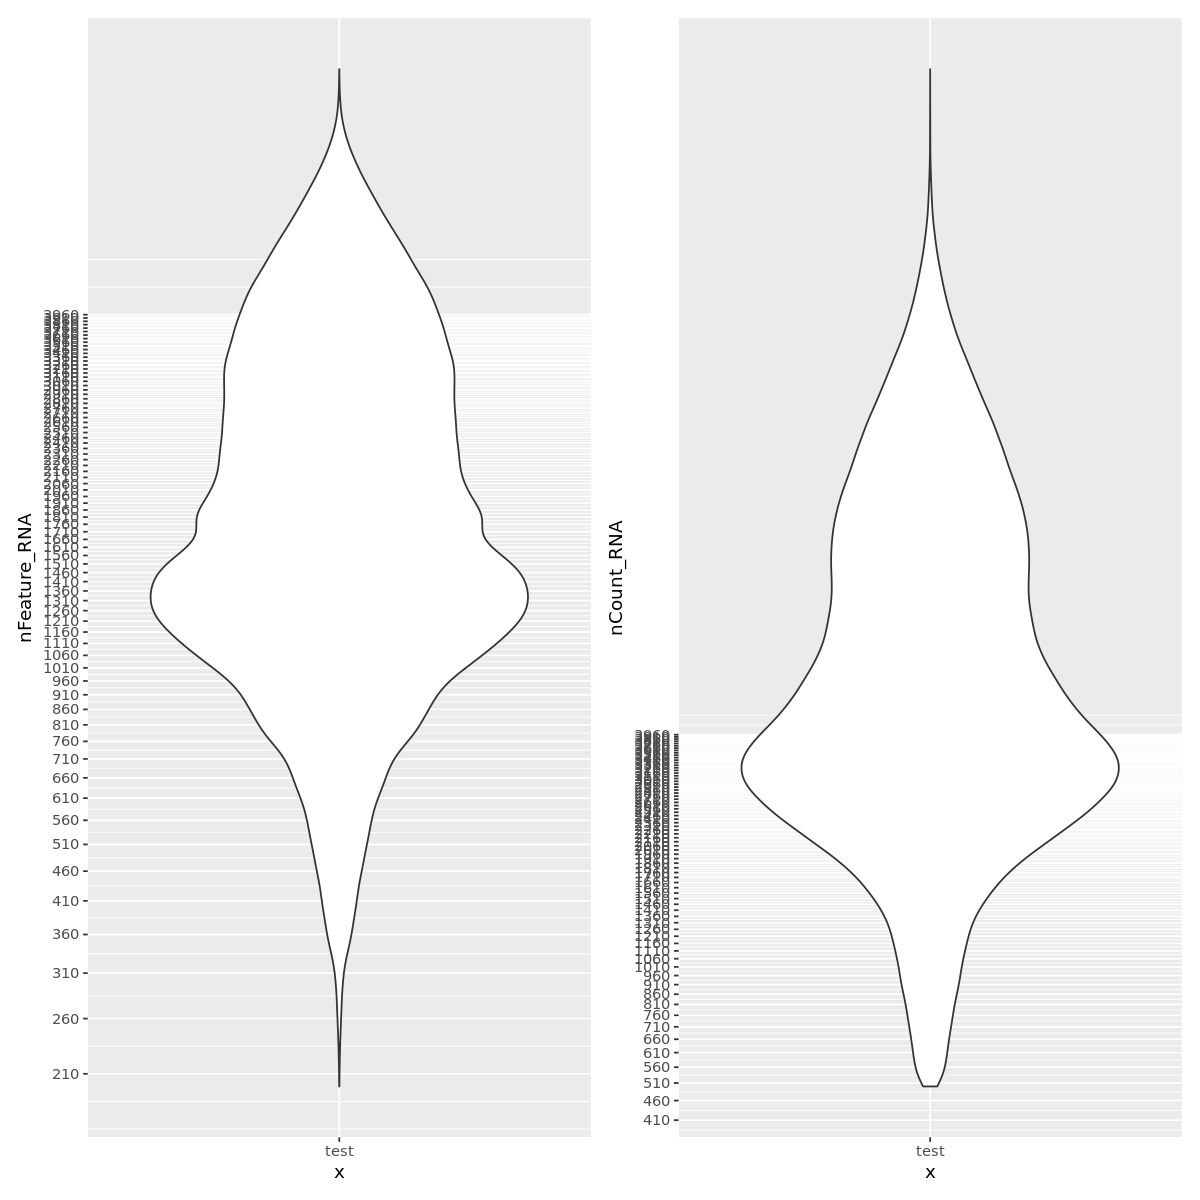

In [11]:
fig.size(10, 10)
obj@meta.data %>% 
    ggplot(aes(x = 'test', y = nFeature_RNA)) +
        geom_violin()+
        scale_y_continuous(trans='log10', breaks = seq(10, 4000, 50)) +
        NULL |
obj@meta.data %>% 
    ggplot(aes(x = 'test', y = nCount_RNA)) +
        geom_violin()+
        scale_y_continuous(trans='log10', breaks = seq(10, 4000, 50)) +
        NULL

# After QC

In [12]:
# Let's not filter by MT since there are tumor cells
# mt_cutoff <- 15
obj <- subset(obj, subset = nFeature_RNA > 200)

In [13]:
obj

An object of class Seurat 
33200 features across 327416 samples within 1 assay 
Active assay: RNA (33200 features, 0 variable features)

# Normalize, var genes, scaling, PCA weighted by `category`

In [14]:
median(colSums(obj@assays$RNA@counts))

[1] 4748

In [15]:
system.time(
obj <- obj %>%
    NormalizeData(normalization.method = "LogNormalize",
                  scale.factor = median(colSums(obj@assays$RNA@counts))) %>%
    FindVariableFeatures(selection.method = "vst", nfeatures = 2000) %>%
    ScaleData() %>%
    RunBalancedPCA(weight.by = "category") # Balance by category so we can see every category nicely in the UMAP
)

Centering and scaling data matrix



   user  system elapsed 
419.941 133.436 402.546 

# UMAP

In [16]:
system.time(
obj <- labUMAP(obj, input_reduc = 'pca', output_reduc = 'umap', key = 'UMAP_',
               min_dist = 0.3, spread = 1.00, n_threads = 20)
)

   user  system elapsed 
634.569   9.371 555.893 

In [18]:
p <- plot_scatter(
    obj@reductions$umap@cell.embeddings, obj@meta.data, 'category',
    point_size = 0.1, no_guides = FALSE, do_labels = FALSE
) +
    labs(x = 'UMAP1', y = 'UMAP2')

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”


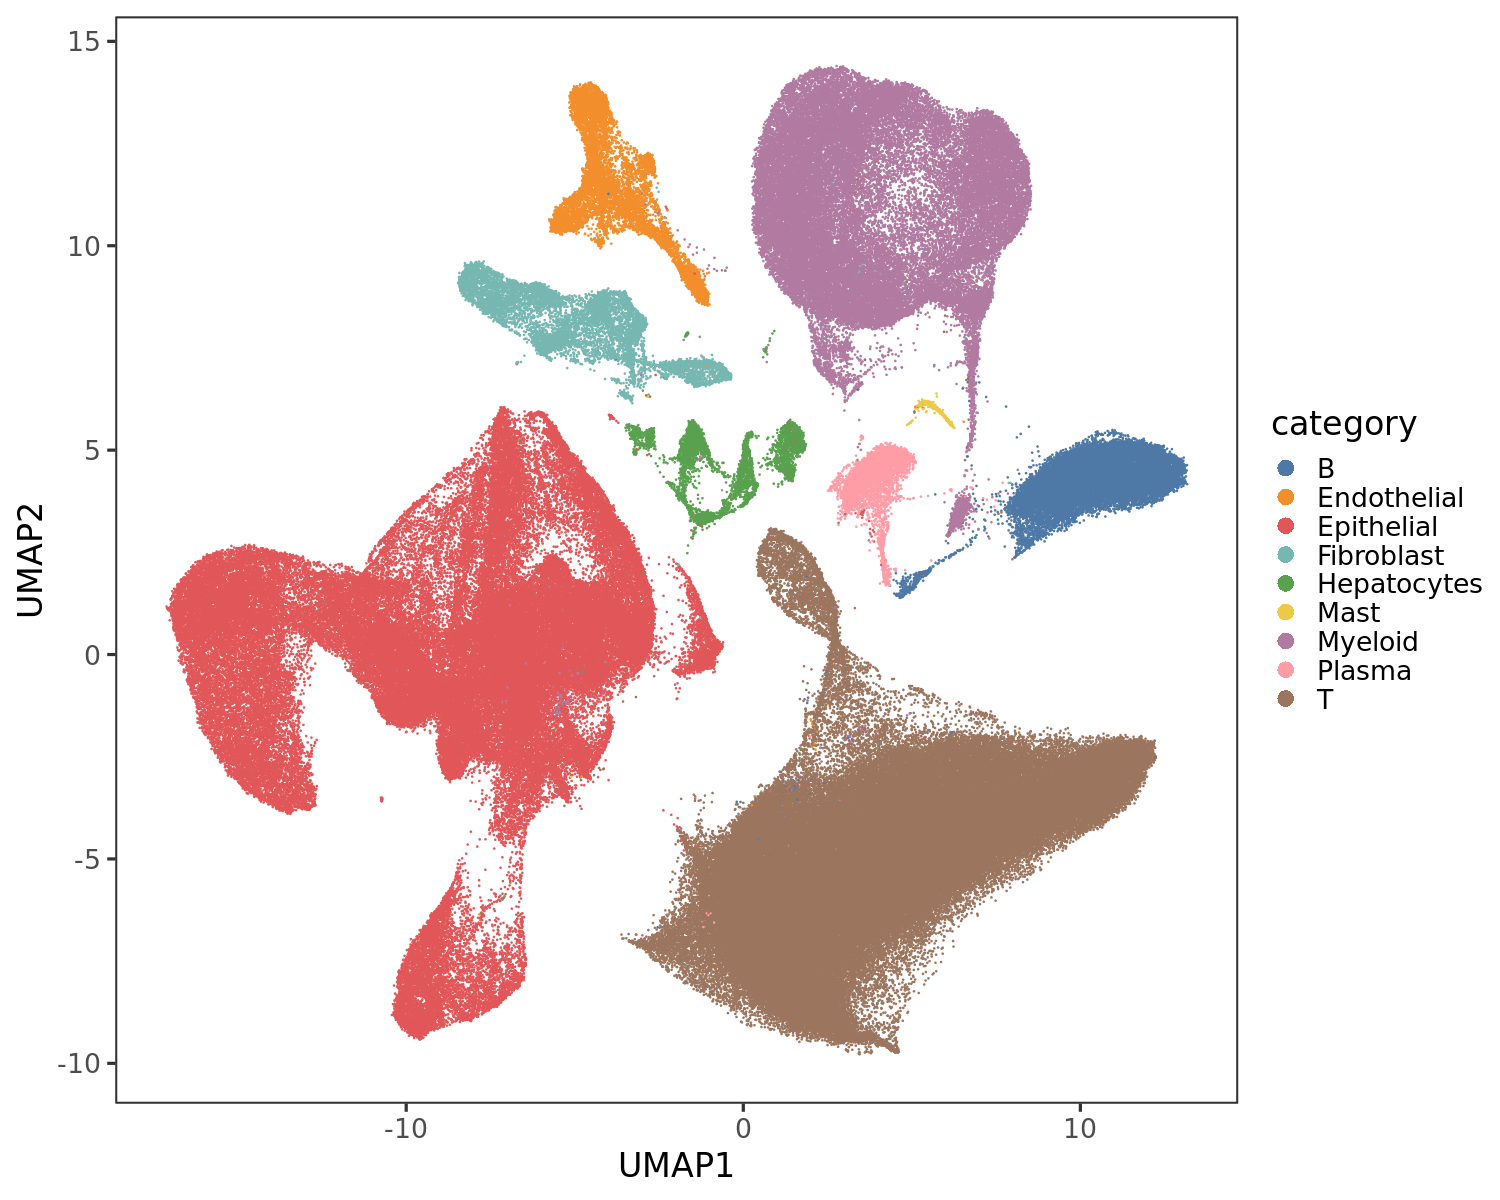

In [19]:
fig.size(10, 12.5)
p